# Einleitung
Im Rahmen des Data-Lab-Kurses wurde ein Machine-Learning‑Projekt entwickelt, das den praktischen Nutzen von Bildklassifikation im Kontext der Mülltrennung untersucht. Ziel des Projekts ist es, anhand von Bilddaten automatisiert zu erkennen, zu welcher Abfallkategorie ein Objekt gehört. Damit adressiert das Projekt ein reales Problem: Fehlwürfe im Abfall führen zu hohen Sortierkosten, mindern die Recyclingqualität und erschweren ressourceneffizientes Handeln. Ein KI‑gestütztes System könnte hier einen Beitrag leisten, indem es Nutzerinnen und Nutzer im Alltag unterstützt oder Sortierprozesse teilautomatisiert.
Ein zentraler Bestandteil des Projekts ist eine saubere und reproduzierbare Datenvorbereitung, die die Grundlage für jedes verlässliche Klassifikationsmodell bildet. Dieser Prozess umfasst die Sichtung, Analyse und Strukturierung des Datensatzes, das Vereinheitlichen der Bildgrößen, das Erstellen eines Train‑Validation‑Test‑Splits sowie das Generieren künstlich erweiterter Trainingsdaten durch Datenaugmentation. Durch diesen systematischen Workflow wurde ein qualitativ hochwertiger, konsistenter und modellfertiger Datensatz aufgebaut, der von der Modellgruppe zur Entwicklung eines neuronalen Klassifikators genutzt werden kann.
Damit leistet das Projekt nicht nur einen Beitrag zum Verständnis moderner Machine‑Learning‑Pipelines, sondern verbindet technische Methodenkompetenz mit einem gesellschaftlich relevanten Anwendungsfall.

# 1. Setup & Bibliotheken

In diesem Schritt laden wir alle benötigten Bibliotheken

In [4]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter
from sklearn.model_selection import train_test_split
import shutil

# 2. Projektpfad setzen und Datensatz prüfen

Wir setzen das Arbeitsverzeichnis auf unseren Projektordner und prüfen, ob der Ordner `dataset-resized

In [9]:
# Arbeitsverzeichnis prüfen
print(os.getcwd())
print(os.listdir())

DATASET_DIR = "dataset-resized"
print("dataset-resized gefunden:", os.path.isdir(DATASET_DIR))

c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash
['.git', 'dataset-224', 'dataset-augmented', 'dataset-resized', 'dataset-split', 'README.md', 'requirements.txt', 'src']
dataset-resized gefunden: True


In [7]:
# kann ggf. weg war um fehler zu behandeln
import os

# Das Notebook-Verzeichnis als Arbeitsverzeichnis setzen
os.chdir(os.getcwd())

# Zeige das aktuelle Arbeitsverzeichnis
print(os.getcwd())

# Zeige Inhalte des Verzeichnisses
print(os.listdir())


c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash\src
['Datenaufbereitung.ipynb', 'Lisa.ipynb', 'muellerkennung.ipynb']


In [8]:
# kann ggf. weg war um fehler zu behandeln
import os

os.chdir(r"c:\Users\GOICY\OneDrive - Bayer\00 Persönlich\03 FHDW\Data Lab\DataLabTrash")

# danach prüfen:
print(os.listdir())


['.git', 'dataset-224', 'dataset-augmented', 'dataset-resized', 'dataset-split', 'README.md', 'requirements.txt', 'src']


# 3. Klassen automatisch einlesen

Wir lesen die vorhandenen

In [10]:
classes = sorted([
    d for d in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, d))
])


# 4. Beispielbilder anzeigen

Wir zeigen je Klasse einige

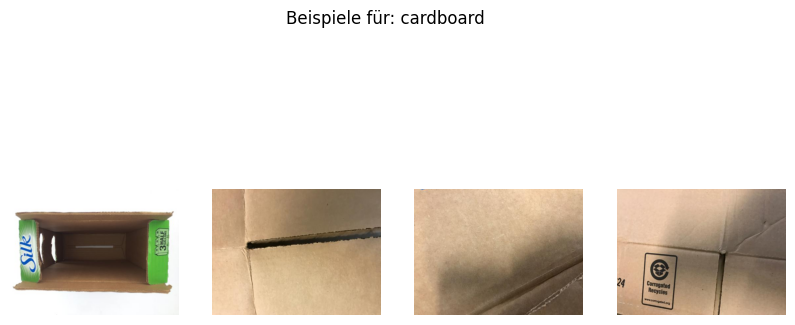

In [11]:
def show_examples(cls, n=4):
    folder = os.path.join(DATASET_DIR, cls)
    files = random.sample(os.listdir(folder), n)

    plt.figure(figsize=(10,5))
    for i, file in enumerate(files):
        img = Image.open(os.path.join(folder, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(f"Beispiele für: {cls}")
    plt.show()

show_examples(classes[0])


# 5. Bildgrößen analysieren

Wir überprüfen, ob alle Bilder die gleiche Größe haben. Das ist wichtig, bevor wir sie auf eine einheitliche Zielgröße (224×224) skalieren.

In [12]:
sizes = []

for cls in classes:
    folder = os.path.join(DATASET_DIR, cls)
    for file in os.listdir(folder):
        img = Image.open(os.path.join(folder, file))
        sizes.append(img.size)

Counter(sizes).most_common(10)

[((512, 384), 2527)]

# 6. Resizing auf 224×224

Wir skalieren alle Bilder auf eine einheitliche Größe von 224×224 Pixeln und speichern sie im Ordner `dataset-224`.

INPUT_DIR = "dataset-resized"
OUTPUT_DIR = "dataset-224"
TARGET_SIZE = (224, 224)

os.makedirs(OUTPUT_DIR, exist_ok=True)

for cls in classes:
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    for file in os.listdir(input_class):
        img = Image.open(os.path.join(input_class, file)).convert("RGB")
        img = img.resize(TARGET_SIZE)
        img.save(os.path.join(output_class, file))

print("Resize abgeschlossen.")

# 7. Train/Validation/Test Split

Wir splitten den Datensatz in 70% Training, 15% Validation und 15% Test.

INPUT_DIR = "dataset-224"
OUTPUT_BASE = "dataset-split"

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(OUTPUT_BASE, split, cls), exist_ok=True)

train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    files = os.listdir(os.path.join(INPUT_DIR, cls))
    
    train_files, temp_files = train_test_split(
        files, test_size=(1-train_ratio), random_state=42
    )
    val_files, test_files = train_test_split(
        temp_files, test_size=(test_ratio/(test_ratio+val_ratio)), random_state=42
    )

    for f in train_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "train", cls, f))
    for f in val_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "val", cls, f))
    for f in test_files:
        shutil.copy(os.path.join(INPUT_DIR, cls, f), os.path.join(OUTPUT_BASE, "test", cls, f))

print("Split abgeschlossen!")

# 8. Datenaugmentation

Wir erweitern die Trainingsdaten um Rotation, Spiegelung und Helligkeits-/Kontrastvariationen.

from PIL import ImageEnhance

INPUT_DIR = "dataset-split/train"
OUTPUT_DIR = "dataset-augmented/train"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def augment_image(img):
    if random.random() < 0.5:
        img = img.rotate(random.randint(-15, 15))
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)
    if random.random() < 0.4:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))
    if random.random() < 0.4:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))
    return img

for cls in classes:
    input_class = os.path.join(INPUT_DIR, cls)
    output_class = os.path.join(OUTPUT_DIR, cls)
    os.makedirs(output_class, exist_ok=True)

    for file in os.listdir(input_class):
        img = Image.open(os.path.join(input_class, file))

        img.save(os.path.join(output_class, file))

        for i in range(2):
            aug = augment_image(img.copy())
            base, ext = os.path.splitext(file)
            aug.save(os.path.join(output_class, f"{base}_aug{i}{ext}"))

print("Augmentation fertig!")

# Fazit
Das durchgeführte Data‑Lab‑Projekt zeigt, wie wichtig eine strukturierte und transparente Datenvorbereitung für den Erfolg eines Machine‑Learning‑Modells ist. Durch die Vereinheitlichung der Bildgrößen, die gezielte Aufteilung in Trainings-, Validierungs- und Testmengen sowie die datenbasierte Erweiterung mittels Augmentation konnte ein belastbarer und vielseitiger Datensatz geschaffen werden. Dieser bildet die Grundlage für ein robustes neuronales Modell, das in der Lage ist, verschiedene Abfalltypen zuverlässig zu unterscheiden.
Darüber hinaus verdeutlicht das Projekt, dass Data‑Preparation weit mehr ist als ein technischer Zwischenschritt: Sie entscheidet maßgeblich über die Modellqualität, die Trainingsstabilität und die spätere Anwendbarkeit der KI. Die im Projekt durchlaufenen Schritte – Datenverständnis, Qualitätssicherung, Bereinigung, Transformation und Erweiterung – spiegeln zentrale Best Practices der modernen Datenwissenschaft wider und zeigen, wie theoretisches Wissen praktisch eingesetzt wird.
Durch den klaren Bezug zur realen Herausforderung der Mülltrennung wird zugleich sichtbar, wie Machine Learning konkrete gesellschaftliche Probleme adressieren kann. Das Projekt liefert damit nicht nur einen funktionierenden technischen Workflow, sondern auch ein Beispiel dafür, wie datengetriebene Lösungen Nachhaltigkeit und Alltagsprozesse unterstützen können.